### Extrapolate using most plausible models discovered.

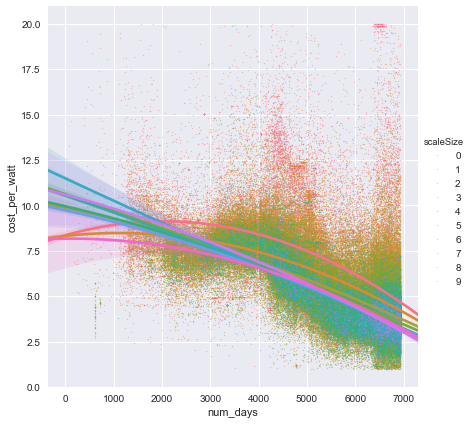

* OLS linear model, three features, time(days), size_kw, state

* model_04: find best OLS (polynomial) model for three features, time, size_kw, state. Requires excluding one-hot encoded state from polynomial expansion. Best poly degree: 14, $R^2$: 0.534.

* model_08_random_forest: Best parameters: {'RFRmax_depth': 15, 'RFRn_estimators': 20} Best R squared: 0.596.

* model_median_01: model the median cost_per_watt with median taken over daily, weekly and monthly time windows. 
    * __weekly best poly degree is 8, $R^2$: 0.849. reasonable extrapolation for 6-8 quarters.__
    * daily best poly degree is 8, with $R^2$: 0.753. reasonable extrapolation for 6-8 quarters.
    * monthly best $R^2$: 0.747 at poly degree 13; predictions very unstable.

* model_median_02: OLS model median of cost as (polynomial) function of two variables, time and size. Size is grouped into 2.5kw wide bins.  
    * __monthly: Best poly_degree: 8; test $R^2$: 0.863. reasonable extrapolation for 6-8 quarters.__
    * weekly: $R^2$: 0.83, poly degree 9). reasonable extrapolation for 6-8 quarters 
    * daily:  ($R^2$: 0.74, poly degree 10). reasonable extrapolation for 6-8 quarters
    
    
#### Note: Before I scaled all the data in the poly pipelines - I haven't done it here.  Is that the difference??


In [1]:
# setup
import datetime

%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rc('figure', figsize=(10, 8))
np.set_printoptions(precision=4, suppress=False)
# please show all columns
pd.set_option("display.max_columns", 60)
import seaborn as sns
sns.set()

# Import sklearn stuff

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error, make_scorer
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline,  make_pipeline, FeatureUnion
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import RandomForestRegressor

In [2]:
# load up
dfMod = pd.read_csv('../local/data/LBNL_openpv_tts_data/model_data_2.csv',
                    index_col='row_id',
                    parse_dates=['install_date'])

In [3]:
# look at some rows
dfMod.sample(n=3).head()

,num_days,num_weeks,num_months,size_kw,scaleSize,state,cost_per_watt,install_date
row_id,,,,,,,,
24703,3171.0,453.0,104.0,4.900000,1.0,CA,6.215918,2006-09-15
205758,5184.0,741.0,170.0,4.600000,1.0,MA,6.413696,2012-03-20
868546,6632.0,948.0,218.0,5.049354,2.0,CA,4.665162,2016-03-07


In [4]:
dfMod.install_date.iloc[0], dfMod.install_date.iloc[-1]

(Timestamp('1998-01-09 00:00:00'), Timestamp('2016-12-31 00:00:00'))

#### Data begins 1998-01-09 and ends 2016-12-31; 19 years

In [5]:
19*365

6935

#### Ranges of the time variables

In [6]:
print(dfMod.iloc[-1, :][['num_days', 'num_weeks', 'num_months']])

num_days      6931
num_weeks      990
num_months     227
Name: 1094908, dtype: object


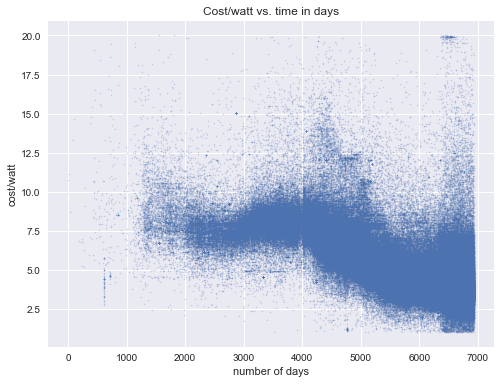

In [7]:
# plot the data
fig, ax = plt.subplots(figsize=(8, 6))
sTitle = 'Cost/watt vs. time in days'

ax.set_title(sTitle)
ax.scatter(dfMod.num_days, dfMod.cost_per_watt,
               marker='.', s=6, alpha=0.2)
ax.set_ylabel('cost/watt')
ax.set_xlabel('number of days')
plt.show();

#### One-hot encode state and shuffle data (remove time ordering, for train_test_split).

In [8]:
dfMod = pd.get_dummies(dfMod.sample(frac=1.0), drop_first=True); dfMod.head(3)

,num_days,num_weeks,num_months,size_kw,scaleSize,cost_per_watt,install_date,state_AZ,state_CA,state_CT,state_DE,state_FL,state_MA,state_MD,state_MN,state_NH,state_NJ,state_NM,state_NV,state_NY,state_OR,state_PA,state_TX,state_VT,state_WI
row_id,,,,,,,,,,,,,,,,,,,,,,,,,
369898,5801.0,829.0,190.0,9.59199,3.0,5.264810,2013-11-27,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
41558,3646.0,521.0,120.0,9.63500,3.0,8.420000,2008-01-03,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1665,1484.0,212.0,49.0,1.93080,0.0,5.772737,2002-02-01,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [9]:
dfMod.columns

Index(['num_days', 'num_weeks', 'num_months', 'size_kw', 'scaleSize',
       'cost_per_watt', 'install_date', 'state_AZ', 'state_CA', 'state_CT',
       'state_DE', 'state_FL', 'state_MA', 'state_MD', 'state_MN', 'state_NH',
       'state_NJ', 'state_NM', 'state_NV', 'state_NY', 'state_OR', 'state_PA',
       'state_TX', 'state_VT', 'state_WI'],
      dtype='object')

---
---

### OLS regression with linear model of time, size and state for baseline.

In [10]:
# features: state, num_days and size_kw 
X = dfMod.drop(['num_weeks', 'num_months', 'scaleSize', 'cost_per_watt', 'install_date'], axis='columns')
y = dfMod[['cost_per_watt']]

R^2: 0.4580
Root Mean Squared Error: 1.5854


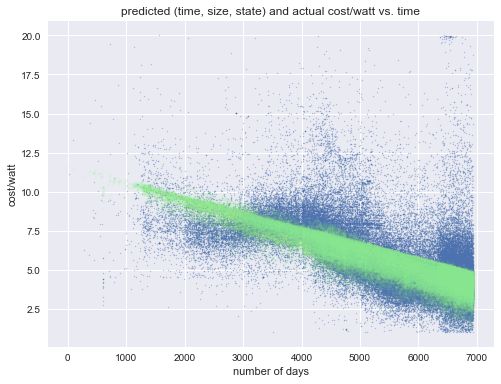

In [11]:
# Create training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30, random_state=42)
# Instantiate the regressor
linReg = LinearRegression()
# Train the model
linReg.fit(X_train, y_train)
# Predict on the test set
yhat = linReg.predict(X_test)
# Compute and print R^2 and RMSE
print("R^2: {:.4f}".format(linReg.score(X_test, y_test)))
rmse = np.sqrt(mean_squared_error(y_test, yhat))
print("Root Mean Squared Error: {:.4f}".format(rmse))

# plot prediction and actual
fig, ax = plt.subplots(figsize=(8, 6))
sTitle = 'predicted (time, size, state) and actual cost/watt vs. time'
ax.set_title(sTitle)
ax.scatter(X_test.num_days, y_test, marker='.', s=5, alpha=0.3,)
ax.scatter(X_test.num_days, linReg.predict(X_test), s=4, alpha=0.1, color='lightgreen')
ax.set_ylabel('cost/watt')
ax.set_xlabel('number of days')
plt.show();

In [12]:
print(linReg.coef_, linReg.intercept_)

[[-0.001  -0.1289 -0.6665  0.1273 -0.2638  0.0282  0.2594  0.0457  0.1554
   0.5861 -0.6193  0.8738 -0.1768 -0.4984 -0.0319 -0.1817  0.1064 -0.8099
  -0.5866 -0.2731]] [11.7562]


#### load prediction data

In [13]:
predData = pd.read_csv('mod_pred_data.csv', index_col=0)

In [14]:
predData.columns

Index(['num_days', 'num_weeks', 'num_months', 'size_kw', 'scaleSize',
       'state_AZ', 'state_CA', 'state_CT', 'state_DE', 'state_FL', 'state_MA',
       'state_MD', 'state_MN', 'state_NH', 'state_NJ', 'state_NM', 'state_NV',
       'state_NY', 'state_OR', 'state_PA', 'state_TX', 'state_VT', 'state_WI'],
      dtype='object')

#### predict on data including time extrapolation

In [15]:
theX=predData.drop(['num_weeks', 'num_months', 'scaleSize'], axis='columns')

In [16]:
theY = linReg.predict(theX)

### Extrapolate 2017 and 2018

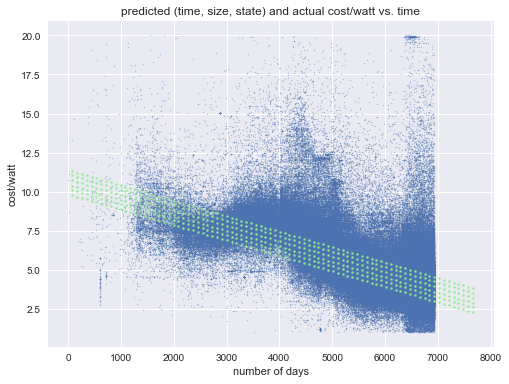

In [17]:
# plot prediction and actual
fig, ax = plt.subplots(figsize=(8, 6))
sTitle = 'predicted (time, size, state) and actual cost/watt vs. time'
ax.set_title(sTitle)
# actual
ax.scatter(X.num_days, y, marker='.', s=5, alpha=0.3,)
# predicted
ax.scatter(theX.num_days, theY, s=4, alpha=1.0, color='lightgreen')
ax.set_ylabel('cost/watt')
ax.set_xlabel('number of days')
plt.show();

---
---

### OLS regression with best polynomal model

#### Make pipeline to transform features

In [18]:
### make it an estimator and a transformer for general use
class ColumnExtractor(BaseEstimator, TransformerMixin):
    def __init__(self, columns=None):
        self.columns = columns
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X_cols = X[self.columns]
        return X_cols

In [19]:
# first, add LR to the pipeline
# take the data apart; numerical vars get scaled, then go to polynomial; state dummies pass through; 
# they get glued back together for the regression.
theStates = ['state_AZ', 'state_CA', 'state_CT', 'state_DE', 'state_FL', 'state_MA',
             'state_MD', 'state_MN', 'state_NH', 'state_NJ', 'state_NM', 'state_NV',
             'state_NY', 'state_OR', 'state_PA', 'state_TX', 'state_VT', 'state_WI']

thePipe = Pipeline([
    ('features', 
     FeatureUnion([('num_vars', 
                    Pipeline([('extract', ColumnExtractor(columns=['num_days', 'size_kw'])),
                              ('scale', StandardScaler()),
                              ('poly', PolynomialFeatures())
                              ])),
                   ('cat_vars',
                    ColumnExtractor(columns=theStates))
                  ]) # end of FeatureUnion
    ),
    ('LR', LinearRegression())
]) # end of Pipeline

In [20]:
thePipe.get_params().keys()

dict_keys(['memory', 'steps', 'features', 'LR', 'features__n_jobs', 'features__transformer_list', 'features__transformer_weights', 'features__num_vars', 'features__cat_vars', 'features__num_vars__memory', 'features__num_vars__steps', 'features__num_vars__extract', 'features__num_vars__scale', 'features__num_vars__poly', 'features__num_vars__extract__columns', 'features__num_vars__scale__copy', 'features__num_vars__scale__with_mean', 'features__num_vars__scale__with_std', 'features__num_vars__poly__degree', 'features__num_vars__poly__include_bias', 'features__num_vars__poly__interaction_only', 'features__cat_vars__columns', 'LR__copy_X', 'LR__fit_intercept', 'LR__n_jobs', 'LR__normalize'])

In [21]:
# features: state, num_days and size_kw 
X = dfMod.drop(['num_weeks', 'num_months', 'scaleSize', 'cost_per_watt', 'install_date'], axis='columns')
y = dfMod[['cost_per_watt']]

R^2: 0.5240
Root Mean Squared Error: 1.4857


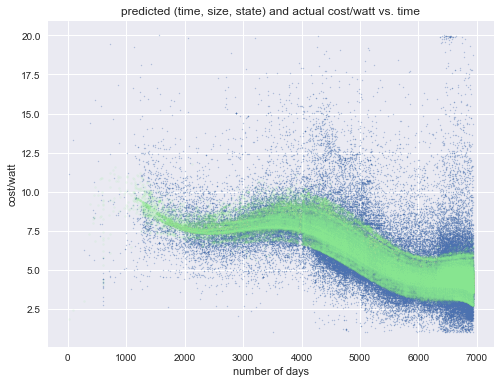

In [22]:
# Create training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30, random_state=42)
# Instantiate the regressor
olsPoly = thePipe
# the best poly degree from grid search
olsPoly.set_params(features__num_vars__poly__degree=6)
# Train the model
olsPoly.fit(X_train, y_train)
# Predict on the test set
yhat = olsPoly.predict(X_test)
# Compute and print R^2 and RMSE
print("R^2: {:.4f}".format(olsPoly.score(X_test, y_test)))
rmse = np.sqrt(mean_squared_error(y_test, yhat))
print("Root Mean Squared Error: {:.4f}".format(rmse))

# plot prediction and actual
fig, ax = plt.subplots(figsize=(8, 6))
sTitle = 'predicted (time, size, state) and actual cost/watt vs. time'
ax.set_title(sTitle)
ax.scatter(X_test.num_days, y_test, marker='.', s=5, alpha=0.3,)
ax.scatter(X_test.num_days, olsPoly.predict(X_test), s=4, alpha=0.1, color='lightgreen')
ax.set_ylabel('cost/watt')
ax.set_xlabel('number of days')
plt.show();

#### Extrapolate 2017 and 2018

In [23]:
theX=predData.drop(['num_weeks', 'num_months', 'scaleSize'], axis='columns')

In [24]:
theX.columns

Index(['num_days', 'size_kw', 'state_AZ', 'state_CA', 'state_CT', 'state_DE',
       'state_FL', 'state_MA', 'state_MD', 'state_MN', 'state_NH', 'state_NJ',
       'state_NM', 'state_NV', 'state_NY', 'state_OR', 'state_PA', 'state_TX',
       'state_VT', 'state_WI'],
      dtype='object')

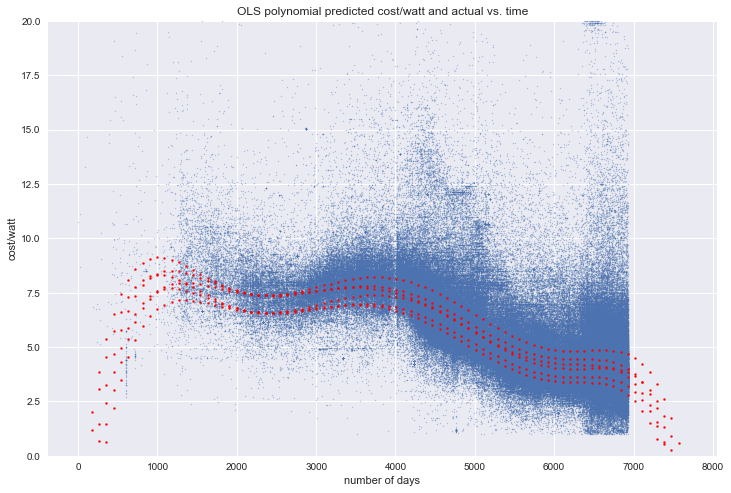

In [25]:
theY = olsPoly.predict(theX)

# plot prediction and actual
fig, ax = plt.subplots(figsize=(12, 8))
sTitle = 'OLS polynomial predicted cost/watt and actual vs. time'
ax.set_title(sTitle)
# actual
ax.scatter(X.num_days, y, marker='.', s=5, alpha=0.3,)
# predicted
ax.scatter(theX.num_days, theY, s=4, alpha=1.0, color='red')
ax.set_ylabel('cost/watt')
ax.set_xlabel('number of days')
ax.set_ylim(0,20)
plt.show();

---
---

### Random Forest Regressor with best parameters

In [26]:
# features: state, num_days and size_kw 
X = dfMod.drop(['num_weeks', 'num_months', 'scaleSize', 'cost_per_watt', 'install_date'], axis='columns')
y = dfMod[['cost_per_watt']]

C:\Users\saus\Anaconda3\lib\site-packages\ipykernel_launcher.py:8: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  


R^2: 0.4580
Root Mean Squared Error: 1.3712


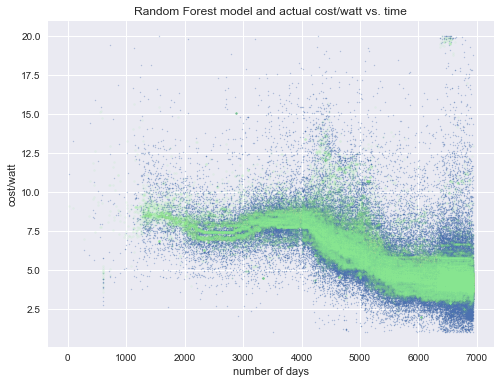

In [27]:
# Create training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30, random_state=42)
# Instantiate the regressor
rfr = RandomForestRegressor()
# set best parameters
rfr.set_params(n_estimators=20, max_depth=15)
# Train the model
rfr.fit(X_train, y_train)
# Predict on the test set
yhat = rfr.predict(X_test)
# Compute and print R^2 and RMSE
print("R^2: {:.4f}".format(linReg.score(X_test, y_test)))
rmse = np.sqrt(mean_squared_error(y_test, yhat))
print("Root Mean Squared Error: {:.4f}".format(rmse))

# plot prediction and actual
fig, ax = plt.subplots(figsize=(8, 6))
sTitle = 'Random Forest model and actual cost/watt vs. time'
ax.set_title(sTitle)
ax.scatter(X_test.num_days, y_test, marker='.', s=5, alpha=0.3,)
ax.scatter(X_test.num_days, rfr.predict(X_test), s=4, alpha=0.1, color='lightgreen')
ax.set_ylabel('cost/watt')
ax.set_xlabel('number of days')
plt.show();

#### predict on data including time extrapolation, 3 sizes and 2 states

In [28]:
theX=predData.drop(['num_weeks', 'num_months', 'scaleSize'], axis='columns')

In [29]:
theY = rfr.predict(theX)

####  Extrapolate RFR for 2017 and 2018

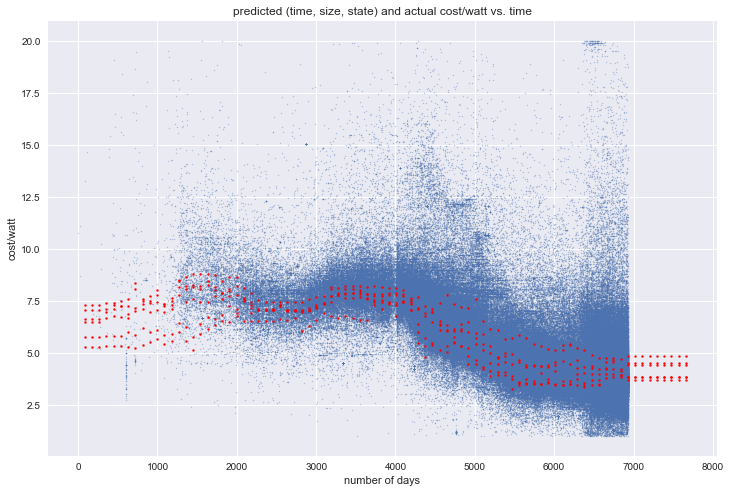

In [30]:
# plot prediction and actual
fig, ax = plt.subplots(figsize=(12, 8))
sTitle = 'predicted (time, size, state) and actual cost/watt vs. time'
ax.set_title(sTitle)
# actual
ax.scatter(X.num_days, y, marker='.', s=5, alpha=0.3,)
# predicted
ax.scatter(theX.num_days, theY, s=4, alpha=1.0, color='red')
ax.set_ylabel('cost/watt')
ax.set_xlabel('number of days')
plt.show();

---
---

### OLS Polynomial of median cost/watt (1 feature, time in weeks)

In [31]:
# get the median by week
by_week = dfMod.groupby(['num_weeks'])
median_week = by_week.cost_per_watt.median()

In [59]:
# make a poly expansion of median (8th degree)
poly8 = PolynomialFeatures(degree=9)

# transform time (num_weeks) to create X
X = poly8.fit_transform(median_week.index.values.reshape(-1, 1))

y = median_week.values.reshape(-1, 1)

R^2: 0.8018
Root Mean Squared Error: 0.8744


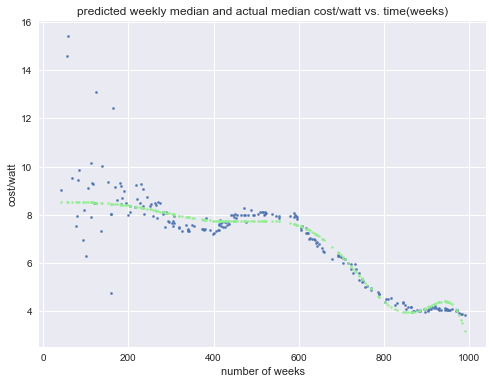

In [60]:
# Create training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=314)
# Instantiate the regressor
lrMedian = LinearRegression()
# Train the model
lrMedian.fit(X_train, y_train)
# Predict on the test set
yhat = lrMedian.predict(X_test)
# Compute and print R^2 and RMSE
print("R^2: {:.4f}".format(lrMedian.score(X_test, y_test)))
rmse = np.sqrt(mean_squared_error(y_test, yhat))
print("Root Mean Squared Error: {:.4f}".format(rmse))

# plot prediction and actual
fig, ax = plt.subplots(figsize=(8, 6))
sTitle = 'predicted weekly median and actual median cost/watt vs. time(weeks)'
ax.set_title(sTitle)
ax.scatter(X_test[:,1], y_test, marker='o', s=5, alpha=1,)
ax.scatter(X_test[:,1], yhat, s=4, alpha=1, color='lightgreen')
ax.set_ylabel('cost/watt')
ax.set_xlabel('number of weeks')
plt.show();

#### predict on data including time extrapolation, 3 sizes and 2 states

### Extrapolate 2017 and 2018

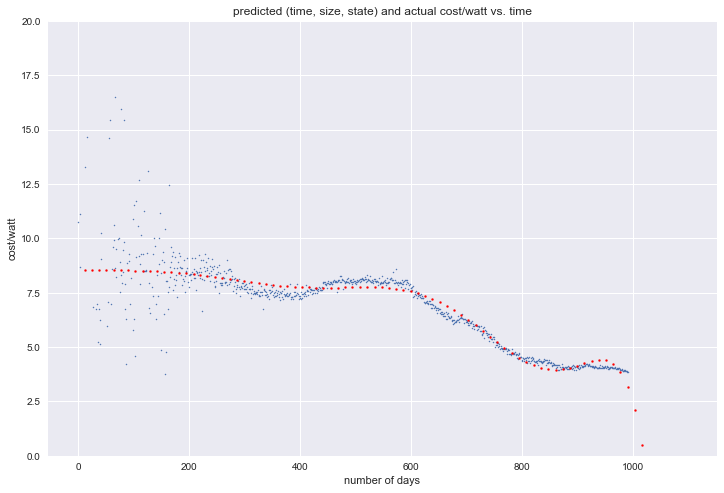

In [61]:
theX = predData.num_weeks[:84]

theY = lrMedian.predict(poly8.fit_transform(theX.values.reshape(-1, 1)))

# plot prediction and actual
fig, ax = plt.subplots(figsize=(12, 8))
sTitle = 'predicted (time, size, state) and actual cost/watt vs. time'
ax.set_title(sTitle)
# actual
ax.scatter(X[:,1], y, marker='.', s=5, alpha=1.0)

# predicted
ax.scatter(theX, theY, s=4, alpha=1.0, marker='o', color='red')
ax.set_ylabel('cost/watt')
ax.set_xlabel('number of days')
ax.set_ylim(0, 20)
plt.show;

---

Add scaling...

---

### OLS Polynomial of median cost/watt (1 feature, time in days)

In [35]:
# get the median by day
by_day = dfMod.groupby(['num_days'])
median_day = by_day.cost_per_watt.median()

In [36]:
# # make a poly expansion of median (8th degree)
poly8 = PolynomialFeatures(degree=9)

# # transform time (num_days) to create X
X = poly8.fit_transform(median_day.index.values.reshape(-1, 1))

y = median_day.values.reshape(-1, 1)

In [37]:
# make a poly expansion with scaling for median (9th degree)
# scalePoly9 = Pipeline([('scale', StandardScaler()), ('poly', PolynomialFeatures())])

R^2: 0.7245
Root Mean Squared Error: 1.0494


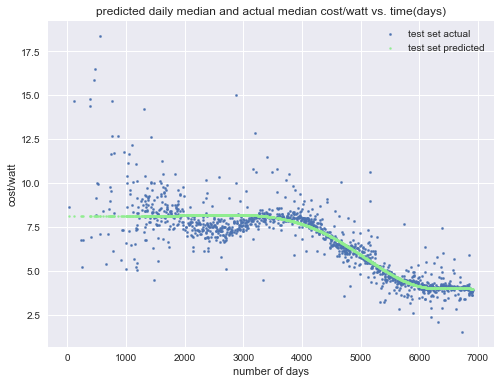

In [38]:
# Create training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=314)
# Instantiate the regressor
lrMedian = LinearRegression()
# Train the model
lrMedian.fit(X_train, y_train)
# Predict on the test set
yhat = lrMedian.predict(X_test)
# Compute and print R^2 and RMSE
print("R^2: {:.4f}".format(lrMedian.score(X_test, y_test)))
rmse = np.sqrt(mean_squared_error(y_test, yhat))
print("Root Mean Squared Error: {:.4f}".format(rmse))

# plot prediction and actual
fig, ax = plt.subplots(figsize=(8, 6))
sTitle = 'predicted daily median and actual median cost/watt vs. time(days)'
ax.set_title(sTitle)
ax.scatter(X_test[:,1], y_test, marker='o', s=5, alpha=1, label='test set actual')
ax.scatter(X_test[:,1], yhat, s=4, alpha=1, color='lightgreen', label='test set predicted')
ax.set_ylabel('cost/watt')
ax.set_xlabel('number of days')
ax.legend()
plt.show();

### Extrapolate 2017 and 2018

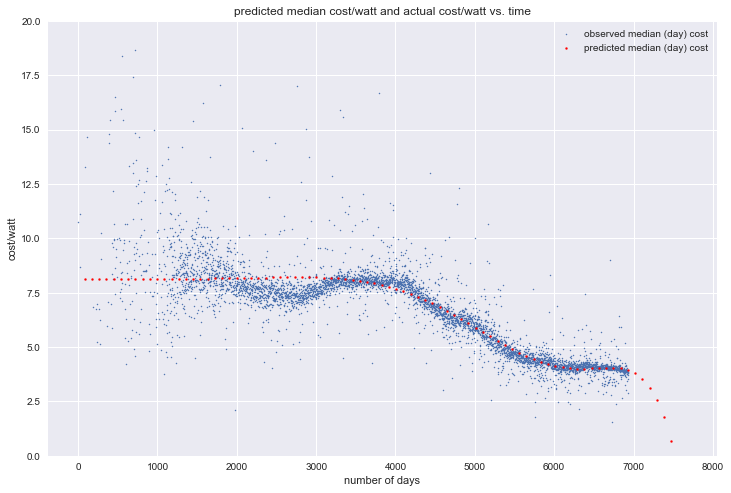

In [39]:
theX = predData.num_days[:84]

theY = lrMedian.predict(poly8.fit_transform(theX.values.reshape(-1, 1)))

# plot prediction and actual
fig, ax = plt.subplots(figsize=(12, 8))
sTitle = 'predicted median cost/watt and actual cost/watt vs. time'
ax.set_title(sTitle)
# actual
ax.scatter(X[:,1], y, marker='.', s=5, alpha=1.0, label='observed median (day) cost')

# predicted
ax.scatter(theX, theY, s=4, alpha=1.0, marker='o', color='red', label='predicted median (day) cost')
ax.set_ylabel('cost/watt')
ax.set_xlabel('number of days')
ax.set_ylim(0,20)
ax.legend()
plt.show();

---

---

### OLS Polynomial of median cost/watt (2 features, time in months, size group)

In [40]:
# get the median by month and size
by_month_size = dfMod.groupby(['num_months', 'scaleSize'])
med_by_month_size = by_month_size.cost_per_watt.median()

dfMedByMonthSize = pd.DataFrame(med_by_month_size).reset_index(); dfMedByMonthSize.head()

,num_months,scaleSize,cost_per_watt
0,0.0,0.0,10.921508
1,1.0,0.0,8.667013
2,3.0,0.0,13.962563
3,6.0,1.0,6.858942
4,7.0,0.0,6.768190


In [41]:
# make a poly expansion for median (8th degree)
poly8 = PolynomialFeatures(degree=8)

X = poly8.fit_transform(dfMedByMonthSize[['num_months', 'scaleSize']].values)
y = dfMedByMonthSize[['cost_per_watt']].values
X.shape, y.shape

((1778, 45), (1778, 1))

R^2: 0.8299
Root Mean Squared Error: 0.7736


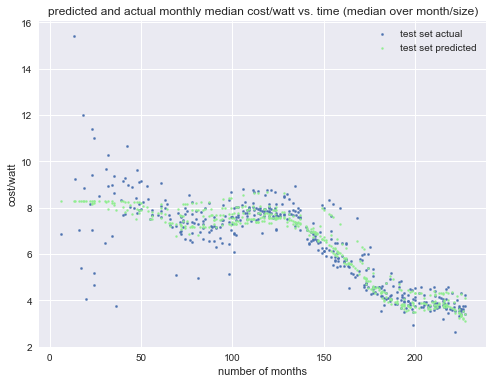

In [42]:
# Create training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=21)
# Instantiate the regressor
lrMedMS = LinearRegression()
# Train the model
lrMedMS.fit(X_train, y_train)
# Predict on the test set
yhat = lrMedMS.predict(X_test)
# Compute and print R^2 and RMSE
print("R^2: {:.4f}".format(lrMedMS.score(X_test, y_test)))
rmse = np.sqrt(mean_squared_error(y_test, yhat))
print("Root Mean Squared Error: {:.4f}".format(rmse))

# plot prediction and actual
fig, ax = plt.subplots(figsize=(8, 6))
sTitle = 'predicted and actual monthly median cost/watt vs. time (median over month/size)'
ax.set_title(sTitle)
ax.scatter(X_test[:,1], y_test, marker='o', s=5, alpha=1, label='test set actual')
ax.scatter(X_test[:,1], yhat, s=4, alpha=1, color='lightgreen', label='test set predicted')
ax.set_ylabel('cost/watt')
ax.set_xlabel('number of months')
ax.legend()
plt.show();

#### predict on data including time extrapolation and 3 most common size groups

### Extrapolate 2017 and 2018

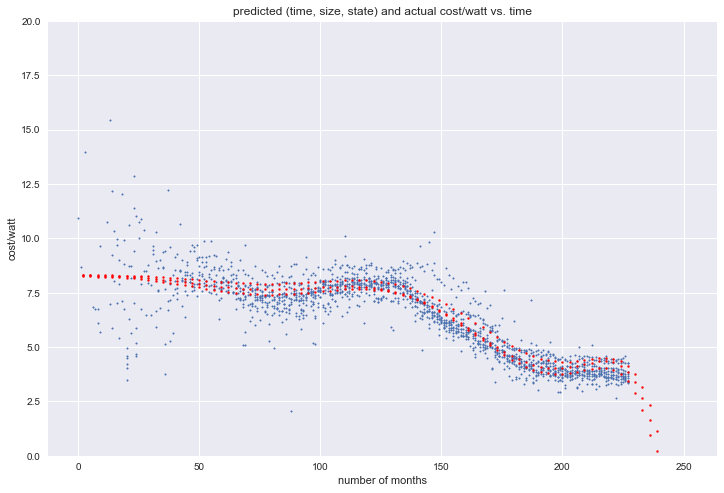

In [43]:
# grab month and size
theRawX = predData[['num_months', 'scaleSize']][:252].values
theX = poly8.fit_transform(theRawX)

# poly8.fit_transform(theX.values.reshape(-1, 1))
theY = lrMedMS.predict(theX)

# plot prediction and actual
fig, ax = plt.subplots(figsize=(12, 8))
sTitle = 'predicted (time, size, state) and actual cost/watt vs. time'
ax.set_title(sTitle)
# actual
ax.scatter(X[:,1], y, marker='.', s=10, alpha=1.0)

# predicted
ax.scatter(theX[:,1], theY, s=4, alpha=1.0, marker='o', color='red')
ax.set_ylabel('cost/watt')
ax.set_xlabel('number of months')
ax.set_ylim(0, 20)
plt.show;

---

---

### OLS Polynomial of median cost/watt (2 features, time in weeks, size group)

In [44]:
# get the median by week and size
by_week_size = dfMod.groupby(['num_weeks', 'scaleSize'])
med_by_week_size = by_week_size.cost_per_watt.median()

dfMedByWeekSize = pd.DataFrame(med_by_week_size).reset_index(); dfMedByWeekSize.head()

,num_weeks,scaleSize,cost_per_watt
0,0.0,0.0,10.734315
1,3.0,0.0,11.108701
2,4.0,0.0,8.667013
3,12.0,0.0,13.270286
4,16.0,0.0,14.654839


In [45]:
#make a poly expansion for median (8th degree)
poly9 = PolynomialFeatures(degree=9)

X = poly9.fit_transform(dfMedByWeekSize[['num_weeks', 'scaleSize']].values)
y = dfMedByWeekSize[['cost_per_watt']].values
X.shape, y.shape

((6598, 55), (6598, 1))

R^2: 0.8047
Root Mean Squared Error: 0.8315


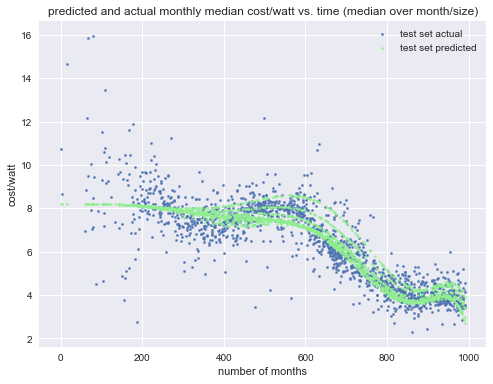

In [46]:
# Create training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=21)
# Instantiate a regressor for weekly data
lrMedWS = LinearRegression()
# Train the model
lrMedWS.fit(X_train, y_train)
# Predict on the test set
yhat = lrMedWS.predict(X_test)
# Compute and print R^2 and RMSE
print("R^2: {:.4f}".format(lrMedWS.score(X_test, y_test)))
rmse = np.sqrt(mean_squared_error(y_test, yhat))
print("Root Mean Squared Error: {:.4f}".format(rmse))

# plot prediction and actual
fig, ax = plt.subplots(figsize=(8, 6))
sTitle = 'predicted and actual monthly median cost/watt vs. time (median over month/size)'
ax.set_title(sTitle)
ax.scatter(X_test[:,1], y_test, marker='o', s=5, alpha=1, label='test set actual')
ax.scatter(X_test[:,1], yhat, s=4, alpha=1, color='lightgreen', label='test set predicted')
ax.set_ylabel('cost/watt')
ax.set_xlabel('number of months')
ax.legend()
plt.show();

#### predict on data including time extrapolation and 3 most common size groups

### Extrapolate 2017 and 2018

In [47]:
# grab month and size
theRawX = predData[['num_weeks', 'scaleSize']][:252].values
theX = poly9.fit_transform(theRawX)

# poly8.fit_transform(theX.values.reshape(-1, 1))
theY = lrMedWS.predict(theX)

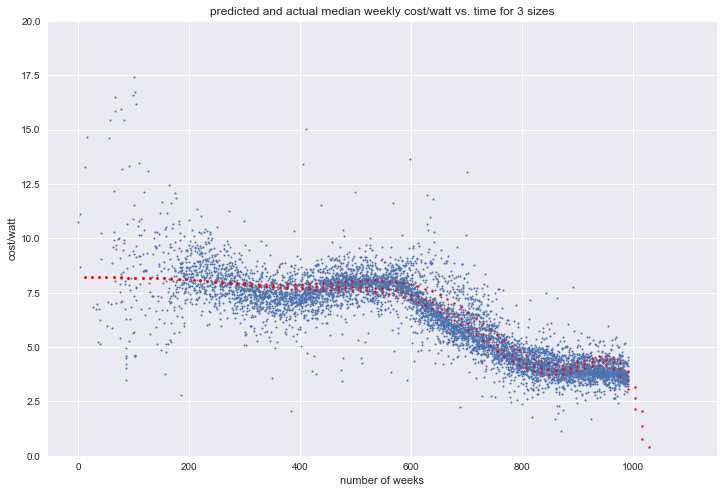

In [48]:
# plot prediction and actual
fig, ax = plt.subplots(figsize=(12, 8))
sTitle = 'predicted and actual median weekly cost/watt vs. time for 3 sizes'
ax.set_title(sTitle)
# actual
ax.scatter(X[:,1], y, marker='.', s=10, alpha=1.0)

# predicted
ax.scatter(theX[:,1], theY, s=4, alpha=1.0, marker='o', color='red')
ax.set_ylabel('cost/watt')
ax.set_xlabel('number of weeks')
ax.set_ylim(0, 20)
plt.show;

---
---


## Now scale, too

I start with unscaled values.

Then I scale and poly transform them.

When I plot actuals, I use the time and cost/watt from the data.

When I plot the predictions, I want to use the original time scale with the predicted ys.


### OLS Polynomial of median cost/watt (2 features, time in weeks, size group)

In [49]:
# get the median by week and size
by_week_size = dfMod.groupby(['num_weeks', 'scaleSize'])
med_by_week_size = by_week_size.cost_per_watt.median()

dfMedByWeekSize = pd.DataFrame(med_by_week_size).reset_index(); dfMedByWeekSize.head()

,num_weeks,scaleSize,cost_per_watt
0,0.0,0.0,10.734315
1,3.0,0.0,11.108701
2,4.0,0.0,8.667013
3,12.0,0.0,13.270286
4,16.0,0.0,14.654839


In [50]:
dfMedByWeekSize.shape

(6598, 3)

In [51]:
# make a poly expansion with scaling for median (9th degree)
scalePoly9 = Pipeline([('scale', StandardScaler()), ('poly', PolynomialFeatures())])

In [52]:
scalePoly9.get_params().keys()

dict_keys(['memory', 'steps', 'scale', 'poly', 'scale__copy', 'scale__with_mean', 'scale__with_std', 'poly__degree', 'poly__include_bias', 'poly__interaction_only'])

In [53]:
scalePoly9.set_params(poly__degree=8)

Pipeline(memory=None,
     steps=[('scale', StandardScaler(copy=True, with_mean=True, with_std=True)), ('poly', PolynomialFeatures(degree=8, include_bias=True, interaction_only=False))])

In [54]:
theRawX = dfMedByWeekSize[['num_weeks', 'scaleSize']]
X = scalePoly9.fit_transform(dfMedByWeekSize[['num_weeks', 'scaleSize']].values)
y = dfMedByWeekSize[['cost_per_watt']].values
X.shape, y.shape

((6598, 45), (6598, 1))

R^2: 0.8386
Root Mean Squared Error: 0.7559


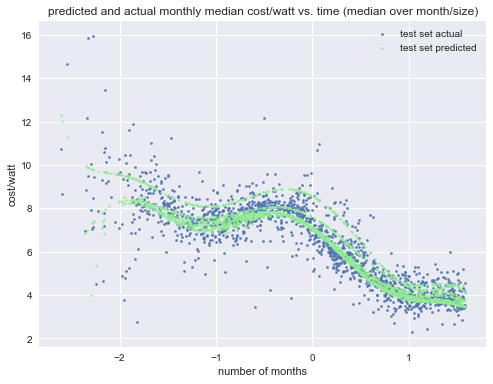

In [55]:
# Create training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=21)
# Instantiate a regressor for weekly data
lrMedWS = LinearRegression()
# Train the model
lrMedWS.fit(X_train, y_train)
# Predict on the test set
yhat = lrMedWS.predict(X_test)
# Compute and print R^2 and RMSE
print("R^2: {:.4f}".format(lrMedWS.score(X_test, y_test)))
rmse = np.sqrt(mean_squared_error(y_test, yhat))
print("Root Mean Squared Error: {:.4f}".format(rmse))

# plot prediction and actual
fig, ax = plt.subplots(figsize=(8, 6))
sTitle = 'predicted and actual monthly median cost/watt vs. time (median over month/size)'
ax.set_title(sTitle)
ax.scatter(X_test[:,1], y_test, marker='o', s=5, alpha=1, label='test set actual')
ax.scatter(X_test[:,1], yhat, s=4, alpha=1, color='lightgreen', label='test set predicted')
ax.set_ylabel('cost/watt')
ax.set_xlabel('number of months')
ax.legend()
plt.show();

#### predict on data including time extrapolation and 3 most common size groups

### Extrapolate 2017 and 2018

In [56]:
# grab month and size
theRawX = predData[['num_weeks', 'scaleSize']][:252]
theX = scalePoly9.fit_transform(theRawX.values)
theY = lrMedWS.predict(theX)

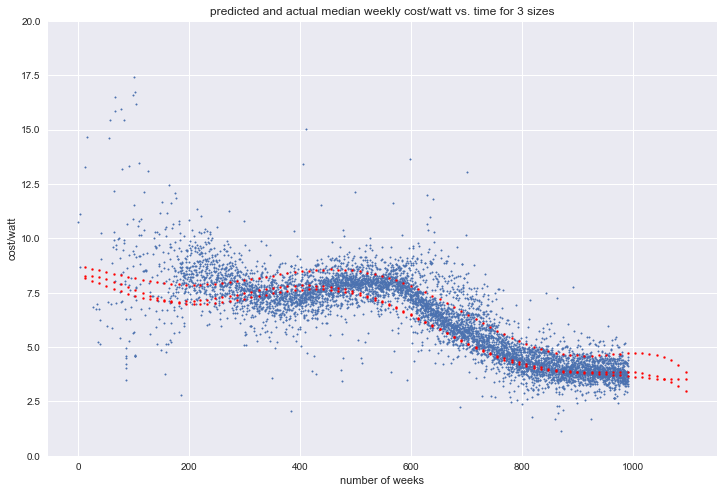

In [57]:
# plot prediction and actual
fig, ax = plt.subplots(figsize=(12, 8))
sTitle = 'predicted and actual median weekly cost/watt vs. time for 3 sizes'
ax.set_title(sTitle)
# actual
ax.scatter(dfMedByWeekSize[['num_weeks']], y, marker='.', s=10, alpha=1.0)

# predicted
ax.scatter(predData[['num_weeks']][:252], theY, s=4, alpha=1.0, marker='o', color='red')
ax.set_ylabel('cost/watt')
ax.set_xlabel('number of weeks')
ax.set_ylim(0, 20)

plt.show;

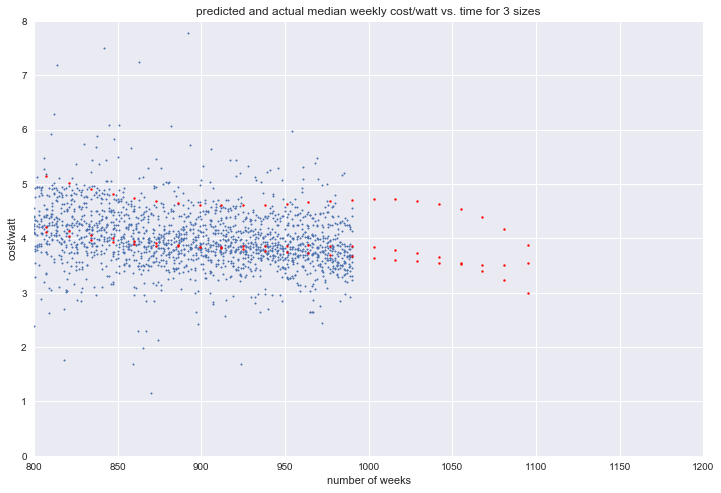

In [58]:
# plot prediction and actual
fig, ax = plt.subplots(figsize=(12, 8))
sTitle = 'predicted and actual median weekly cost/watt vs. time for 3 sizes'
ax.set_title(sTitle)
# actual
ax.scatter(dfMedByWeekSize[['num_weeks']], y, marker='.', s=10, alpha=1.0)

# predicted
ax.scatter(predData[['num_weeks']][:252], theY, s=4, alpha=1.0, marker='o', color='red')
ax.set_ylabel('cost/watt')
ax.set_xlabel('number of weeks')
ax.set_ylim(0, 8)
ax.set_xlim(800, 1200)
plt.show;